# Random Forest Project

For this project we will be exploring publicly available data from [LendingClub.com](https://www.lendingclub.com/). We will use lending data from 2007-2010 and be trying to classify and predict whether or not the borrower paid back their loan in full.

# Import Libraries

**Import the usual libraries for pandas and plotting.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Get the Data

**Use pandas to read loan_data.csv as a dataframe called loans.**

In [3]:
loans = pd.read_csv(r'C:\Users\User\Dropbox\Term 2252\ARTI 308\Labs\Lab9\loan_data.csv')

**Check out the info(), head(), and describe() methods on loans.**

In [4]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [5]:
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [6]:
loans.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


# Exploratory Data Analysis

**Create a histogram of two FICO distributions on top of each other, one for each credit.policy outcome.**

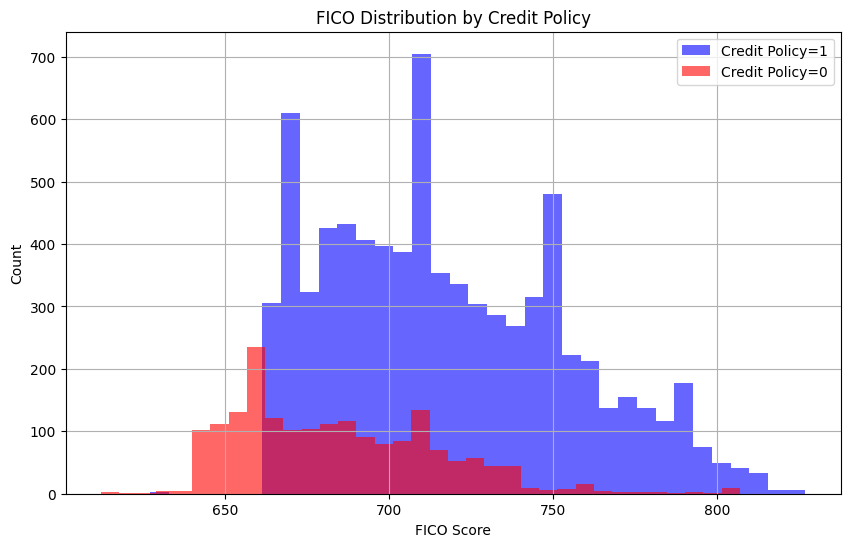

In [7]:
plt.figure(figsize=(10, 6))
loans[loans['credit.policy'] == 1]['fico'].hist(bins=35, color='blue', label='Credit Policy=1', alpha=0.6)
loans[loans['credit.policy'] == 0]['fico'].hist(bins=35, color='red', label='Credit Policy=0', alpha=0.6)
plt.legend()
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.title('FICO Distribution by Credit Policy')
plt.show()

**Create a similar figure, except this time select by the not.fully.paid column.**

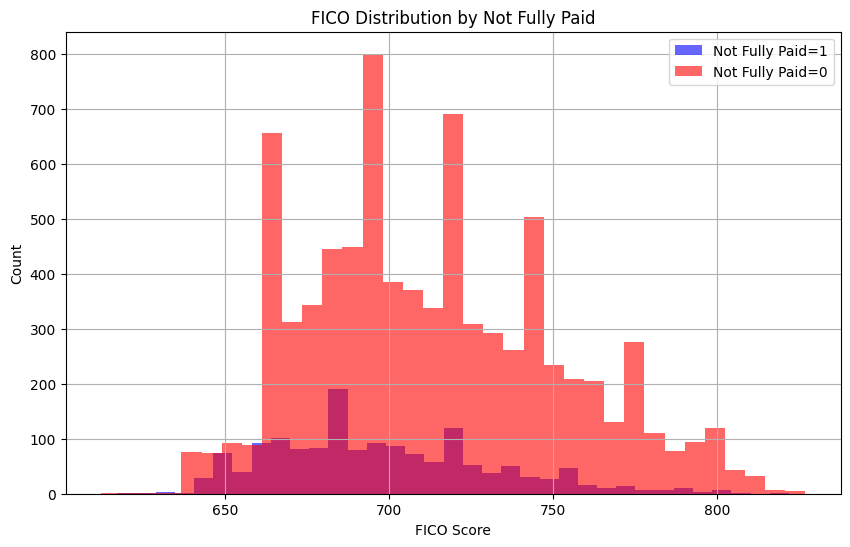

In [8]:
plt.figure(figsize=(10, 6))
loans[loans['not.fully.paid'] == 1]['fico'].hist(bins=35, color='blue', label='Not Fully Paid=1', alpha=0.6)
loans[loans['not.fully.paid'] == 0]['fico'].hist(bins=35, color='red', label='Not Fully Paid=0', alpha=0.6)
plt.legend()
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.title('FICO Distribution by Not Fully Paid')
plt.show()

**Create a countplot using seaborn showing the counts of loans by purpose, with the color hue defined by not.fully.paid.**

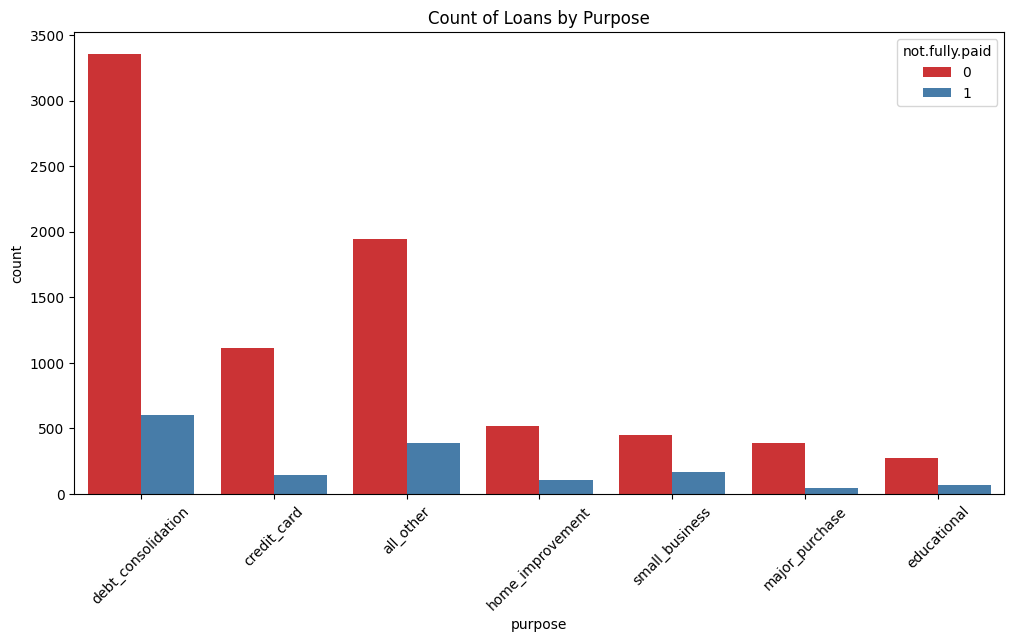

In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(x='purpose', hue='not.fully.paid', data=loans, palette='Set1')
plt.title('Count of Loans by Purpose')
plt.xticks(rotation=45)
plt.show()

**Let's see the trend between FICO score and interest rate. Recreate the following jointplot.**

In [ ]:
sns.jointplot(x='fico', y='int.rate', data=loans, color='purple')
plt.show()

**Create the following lmplots to see if the trend differed between not.fully.paid and credit.policy.**

In [ ]:
sns.lmplot(x='fico', y='int.rate', data=loans, hue='credit.policy',
           col='not.fully.paid', palette='Set1')
plt.show()

# Setting up the Data

**Check loans.info() again.**

In [ ]:
loans.info()

## Categorical Features

**Create a list of 1 element containing the string 'purpose'. Call this list cat_feats.**

In [ ]:
cat_feats = ['purpose']

**Use pd.get_dummies to create final_data.**

In [ ]:
final_data = pd.get_dummies(loans, columns=cat_feats, drop_first=True)
final_data.head()

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = final_data.drop('not.fully.paid', axis=1)
y = final_data['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

## Training a Decision Tree Model

**Import DecisionTreeClassifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

**Create an instance of DecisionTreeClassifier() called dtree and fit it to the training data.**

In [ ]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

## Predictions and Evaluation of Decision Tree

**Create predictions from the test set and create a classification report and a confusion matrix.**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

pred_dtree = dtree.predict(X_test)

print('Decision Tree - Confusion Matrix:')
print(confusion_matrix(y_test, pred_dtree))
print()
print('Decision Tree - Classification Report:')
print(classification_report(y_test, pred_dtree))

## Training the Random Forest Model

**Create an instance of the RandomForestClassifier class and fit it to our training data.**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=600)
rfc.fit(X_train, y_train)

## Predictions and Evaluation

**Predict the class of not.fully.paid for the X_test data.**

In [ ]:
pred_rfc = rfc.predict(X_test)

**Now create a classification report from the results.**

In [ ]:
print('Random Forest - Classification Report:')
print(classification_report(y_test, pred_rfc))

**Show the Confusion Matrix for the predictions.**

In [ ]:
print('Random Forest - Confusion Matrix:')
print(confusion_matrix(y_test, pred_rfc))

**What performed better the random forest or the decision tree?**

The **Random Forest** performed better than the Decision Tree overall. Random Forest has higher accuracy because it combines predictions from multiple decision trees (600 in this case), which reduces overfitting and improves generalization. However, note that both models struggle with recall for class 1 (not fully paid) due to class imbalance in the dataset — there are far more fully paid loans than not fully paid ones.